# Phase 3 — Détection Statistique d'Anomalies
## Système de Surveillance Intelligent — Bourse de Casablanca

**Objectif :** Identifier les valeurs anormales sur tous les indicateurs calculés en Phase 2, 
à l'aide de seuils statistiques rigoureux, et produire un rapport d'alertes pour validation.

### Méthodes de détection utilisées

| Méthode | Principe | Adapté pour |
|---|---|---|
| **Z-score statique** | \|x - μ\| / σ > seuil | Séries stationnaires |
| **Z-score rolling** | \|x - μ_window\| / σ_window | Séries en tendance |
| **Percentile P95/P99** | Valeur > P99 ou < P1 | Distributions asymétriques |
| **IQR (Tukey)** | x > Q3 + k×IQR | Robuste aux outliers |
| **Bandes de Bollinger** | x > moy ± k×σ rolling | Prix / cours évolutifs |
| **CUSUM** | Somme cumulative des écarts | Dérives graduelles |

**Consensus** : une anomalie est confirmée si ≥ 2 méthodes la détectent simultanément.

---
## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from src.anomaly_detector import (
    detect_market_anomalies,
    detect_instrument_anomalies,
    detect_orderflow_anomalies,
    consolidate_all_anomalies,
    compute_seuils_table,
    export_anomalies_excel,
    summarize_anomalies,
    detect_multi_method,
    CRITIQUE, MODERE, FAIBLE, NORMAL,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

SEV_COLORS = {NORMAL: '#4CAF50', FAIBLE: '#FFC107', MODERE: '#FF9800', CRITIQUE: '#F44336'}
print('✓ Imports OK')

✓ Imports OK


---
## 1. Chargement des données Phase 2

In [2]:
DATA = '../data'
df_market = pd.read_parquet(f'{DATA}/market_indicators.parquet')
df_instr  = pd.read_parquet(f'{DATA}/instrument_indicators.parquet')
df_of     = pd.read_parquet(f'{DATA}/orderflow_indicators.parquet')

# Conversion dates
for df in [df_market, df_instr, df_of]:
    df['Jour'] = pd.to_datetime(df['Jour'])

print('Données chargées :')
print(f'  Marché     : {len(df_market)} séances')
print(f'  Instruments: {len(df_instr):,} lignes | {df_instr["Ticker"].nunique()} titres')
print(f'  Order Flow : {len(df_of):,} lignes | {df_of["Ticker"].nunique()} titres | {df_of["Jour"].nunique()} jours')

Données chargées :
  Marché     : 247 séances
  Instruments: 19,164 lignes | 80 titres
  Order Flow : 1,549 lignes | 77 titres | 23 jours


---
## 2. Tableau des Seuils Statistiques
> Référence pour validation avec l'encadrante

In [3]:
df_seuils = compute_seuils_table(df_instr, df_market, df_of)
print(f'Seuils calculés pour {len(df_seuils)} indicateurs')
display(df_seuils.style
        .format({'Moyenne': '{:.4f}', 'Écart-type': '{:.4f}',
                 'P1': '{:.4f}', 'P95': '{:.4f}', 'P99': '{:.4f}',
                 'Seuil_Alerte_Bas': '{:.4f}', 'Seuil_Alerte_Haut': '{:.4f}',
                 'Seuil_Critique_Bas': '{:.4f}', 'Seuil_Critique_Haut': '{:.4f}'})
        .background_gradient(subset=['P99', 'Seuil_Critique_Haut'], cmap='Reds')
        .set_caption('Tableau des Seuils Statistiques — BVC 2025'))

Seuils calculés pour 16 indicateurs


,Niveau,Indicateur,Méthode,N,Moyenne,Écart-type,Médiane,P1,P5,P95,P99,Seuil_Alerte_Bas,Seuil_Alerte_Haut,Seuil_Critique_Bas,Seuil_Critique_Haut
0,Marché Global,Volume Marché (MAD),Z-score + Percentile,247,489006783.5682,324791480.2626,428109975.220000,87520338.9064,159160873.467000,1020713248.6740,1420728479.7404,-160576176.9569,1138589744.0933,-485367657.2194,1463381224.3559
1,Marché Global,Volume Relatif Marché,Z-score + Percentile,243,1.0319,0.6023,0.916500,0.2559,0.322300,1.9555,2.7993,-0.1727,2.2366,-0.7751,2.8389
2,Marché Global,MASI Rendement (%),Z-score + Percentile,246,0.0937,0.8710,0.102600,-2.2342,-1.339400,1.6179,2.5016,-1.6482,1.8357,-2.5192,2.7066
3,Marché Global,MASI Volatilité 20j,Z-score + Percentile,237,0.8136,0.3095,0.761500,0.3912,0.438200,1.5036,1.6728,0.1945,1.4326,-0.1150,1.7421
4,Marché Global,Breadth (% hausse),Z-score + Percentile,247,38.4400,13.3887,37.837800,8.6133,16.438400,59.7918,69.2259,11.6625,65.2175,-1.7263,78.6062
5,Instrument,Rendement Instrument (%),Z-score + Percentile,18319,0.1467,2.5134,0.000000,-6.4429,-3.614500,4.7094,9.9140,-4.8801,5.1735,-7.3935,7.6869
6,Instrument,Volatilité 5j (%),Z-score + Percentile,18165,1.9819,1.4855,1.684200,0.0000,0.019700,4.8798,6.9709,-0.9892,4.9530,-2.4748,6.4385
7,Instrument,Volatilité 20j (%),Z-score + Percentile,17626,2.2222,1.1306,2.001900,0.0981,0.799900,4.3120,5.7497,-0.0390,4.4833,-1.1696,5.6139
8,Instrument,Volume Relatif Instrument,Z-score + Percentile,15793,1.0366,1.5489,0.504200,0.0036,0.022000,3.8804,7.8556,-2.0613,4.1345,-3.6102,5.6834
9,Instrument,Spread Bid-Ask (%),Z-score + Percentile,17787,3.9875,4.1243,2.891400,0.2105,0.609100,10.9978,23.7006,-4.2611,12.2361,-8.3854,16.3604


---
## 3. Détection — Niveau Marché Global

In [4]:
print('Détection anomalies marché global...')
df_market_anom = detect_market_anomalies(df_market)
print(f'\nAnomalies détectées — Marché Global : {len(df_market_anom)}')
print(df_market_anom['Severite_Finale'].value_counts().to_string())
print()
display(df_market_anom.head(30))

Détection anomalies marché global...



Anomalies détectées — Marché Global : 213
Severite_Finale
Faible      160
Modéré       44
Critique      9



,Jour,Ticker,Niveau,Indicateur,Valeur,Severite_Finale,Score_Consensus,Nb_Methodes_Alerte
0,2025-12-26,MARCHE,Marché Global,Volume_MAD,"3,352,763,404.7500",Critique,3.0000,4
1,2025-12-26,MARCHE,Marché Global,Volume_Relatif_Marche,5.6838,Critique,3.0000,3
2,2025-04-22,MARCHE,Marché Global,HHI_Volume,0.6181,Critique,3.0000,3
3,2025-07-22,MARCHE,Marché Global,HHI_Volume,0.4608,Critique,3.0000,3
4,2025-11-12,MARCHE,Marché Global,HHI_Volume,0.4446,Critique,3.0000,3
5,2025-04-10,MARCHE,Marché Global,MASI_Return_pct,3.1628,Critique,2.7500,4
6,2025-03-21,MARCHE,Marché Global,Volume_Relatif_Marche,2.9204,Critique,2.6667,3
7,2025-12-19,MARCHE,Marché Global,Volume_Relatif_Marche,3.3793,Critique,2.6667,3
8,2025-04-08,MARCHE,Marché Global,MASI_Return_pct,-2.5813,Critique,2.5000,4
9,2025-02-26,MARCHE,Marché Global,Volume_Relatif_Marche,2.2341,Faible,1.3333,2


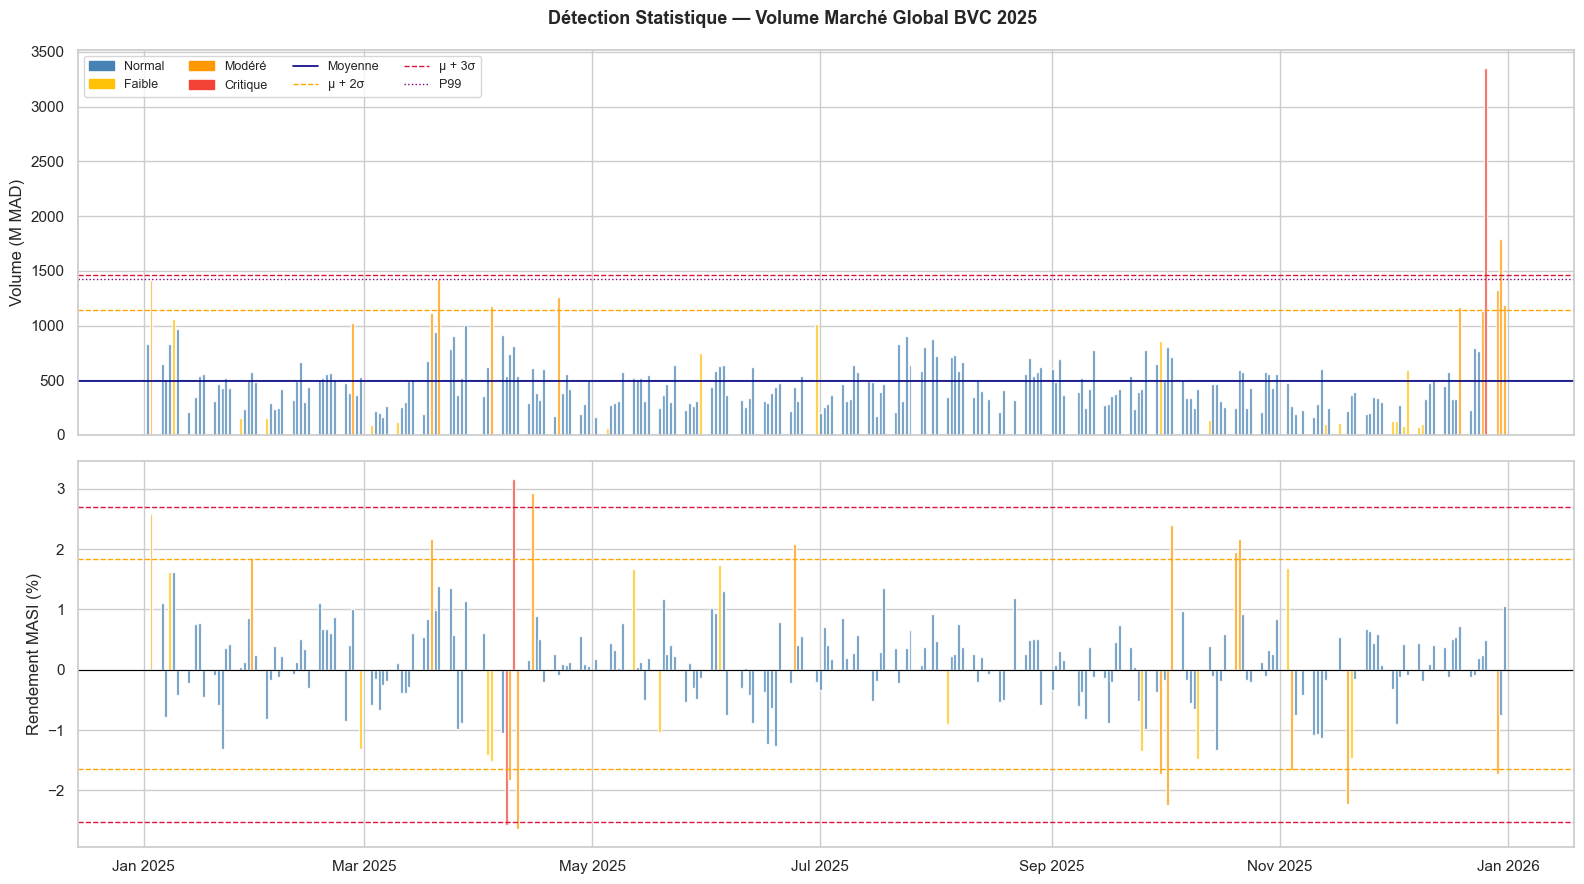

In [5]:
# Visualisation : Volume journalier avec anomalies colorées
df_vol = df_market[['Jour', 'Volume_MAD']].copy()
# Détection multi-méthodes sur le volume
vol_det = detect_multi_method(
    df_market.set_index('Jour')['Volume_MAD'],
    methods=['zscore', 'rolling_zscore', 'percentile', 'iqr']
).reset_index().rename(columns={'index': 'Jour'})

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Détection Statistique — Volume Marché Global BVC 2025', fontsize=13, fontweight='bold')

# Volume coloré par sévérité
sev_colors_map = {NORMAL: 'steelblue', FAIBLE: '#FFC107', MODERE: '#FF9800', CRITIQUE: '#F44336'}
for _, row in vol_det.iterrows():
    color = sev_colors_map.get(row['Severite_Finale'], 'steelblue')
    axes[0].bar(row['Jour'], row['Valeur'] / 1e6, color=color, alpha=0.85, width=0.8)

# Seuils
vol_s = df_market['Volume_MAD']
axes[0].axhline(vol_s.mean() / 1e6, color='navy', linestyle='-', linewidth=1.2, label='Moyenne')
axes[0].axhline((vol_s.mean() + 2*vol_s.std()) / 1e6, color='orange', linestyle='--', linewidth=1, label='μ + 2σ')
axes[0].axhline((vol_s.mean() + 3*vol_s.std()) / 1e6, color='crimson', linestyle='--', linewidth=1, label='μ + 3σ')
axes[0].axhline(vol_s.quantile(0.99) / 1e6, color='purple', linestyle=':', linewidth=1, label='P99')
axes[0].set_ylabel('Volume (M MAD)')
patches = [mpatches.Patch(color=v, label=k) for k, v in sev_colors_map.items()]
axes[0].legend(handles=patches + axes[0].get_lines(), ncols=4, fontsize=9)

# MASI rendement avec anomalies
if 'MASI_Return_pct' in df_market.columns:
    masi_det = detect_multi_method(
        df_market.set_index('Jour')['MASI_Return_pct'],
        methods=['zscore', 'rolling_zscore', 'percentile', 'iqr']
    ).reset_index().rename(columns={'index': 'Jour'})
    for _, row in masi_det.iterrows():
        color = sev_colors_map.get(row['Severite_Finale'], 'steelblue')
        axes[1].bar(row['Jour'], row['Valeur'], color=color, alpha=0.85, width=0.8)
    axes[1].axhline(0, color='black', linewidth=0.8)
    ret_s = df_market['MASI_Return_pct'].dropna()
    axes[1].axhline(ret_s.mean() + 2*ret_s.std(), color='orange', linestyle='--', linewidth=1)
    axes[1].axhline(ret_s.mean() - 2*ret_s.std(), color='orange', linestyle='--', linewidth=1)
    axes[1].axhline(ret_s.mean() + 3*ret_s.std(), color='crimson', linestyle='--', linewidth=1)
    axes[1].axhline(ret_s.mean() - 3*ret_s.std(), color='crimson', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Rendement MASI (%)')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../reports/12_detection_marche.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Détection — Niveau Instrument

In [6]:
print('Détection anomalies par instrument (cela peut prendre 1-2 minutes)...')
df_instr_anom = detect_instrument_anomalies(df_instr, min_seances=30)
print(f'\nAnomalies instruments : {len(df_instr_anom):,}')
print('\nPar sévérité :')
print(df_instr_anom['Severite_Finale'].value_counts().to_string())
print('\nPar indicateur :')
print(df_instr_anom['Indicateur'].value_counts().to_string())

Détection anomalies par instrument (cela peut prendre 1-2 minutes)...



Anomalies instruments : 16,656

Par sévérité :
Severite_Finale
Faible      10813
Modéré       4112
Critique     1731

Par indicateur :
Indicateur
Rendement_pct     4937
Volatilite_20j    3841
Volume_Relatif    2235
Spread_pct        1991
Turnover_Ratio    1884
RSI_14j           1768


In [7]:
# Top 25 anomalies critiques instruments
critiques = df_instr_anom[df_instr_anom['Severite_Finale'] == CRITIQUE]
print(f'=== ANOMALIES CRITIQUES INSTRUMENTS : {len(critiques)} ===')
display(critiques[['Jour','Ticker','Libelle','Indicateur','Description',
                    'Valeur','Score_Consensus','Nb_Methodes_Alerte']].head(25))

=== ANOMALIES CRITIQUES INSTRUMENTS : 1731 ===


,Jour,Ticker,Libelle,Indicateur,Description,Valeur,Score_Consensus,Nb_Methodes_Alerte
0,2025-03-20,ADH,DOUJA PROM ADDOHA,Rendement_pct,Rendement anormal,9.9854,3.0000,4
1,2025-09-01,ADH,DOUJA PROM ADDOHA,Rendement_pct,Rendement anormal,9.9740,3.0000,4
2,2025-03-20,ADH,DOUJA PROM ADDOHA,Volume_Relatif,Spike de volume,5.6282,3.0000,3
3,2025-09-01,ADH,DOUJA PROM ADDOHA,Volume_Relatif,Spike de volume,6.4598,3.0000,3
4,2025-10-21,ADH,DOUJA PROM ADDOHA,Volume_Relatif,Spike de volume,4.7034,3.0000,3
5,2025-01-02,ADH,DOUJA PROM ADDOHA,Turnover_Ratio,Turnover anormal,0.0065,3.0000,2
6,2025-01-03,ADH,DOUJA PROM ADDOHA,Turnover_Ratio,Turnover anormal,0.0077,3.0000,2
7,2025-09-01,ADH,DOUJA PROM ADDOHA,Turnover_Ratio,Turnover anormal,0.0085,3.0000,2
8,2025-01-21,ADH,DOUJA PROM ADDOHA,RSI_14j,RSI extrême (survente/surachat),35.0531,3.0000,1
9,2025-03-20,ADH,DOUJA PROM ADDOHA,RSI_14j,RSI extrême (survente/surachat),68.1507,3.0000,1


Instrument le plus alerté : NEJ — AUTO NEJMA
Nombre d'anomalies : 441


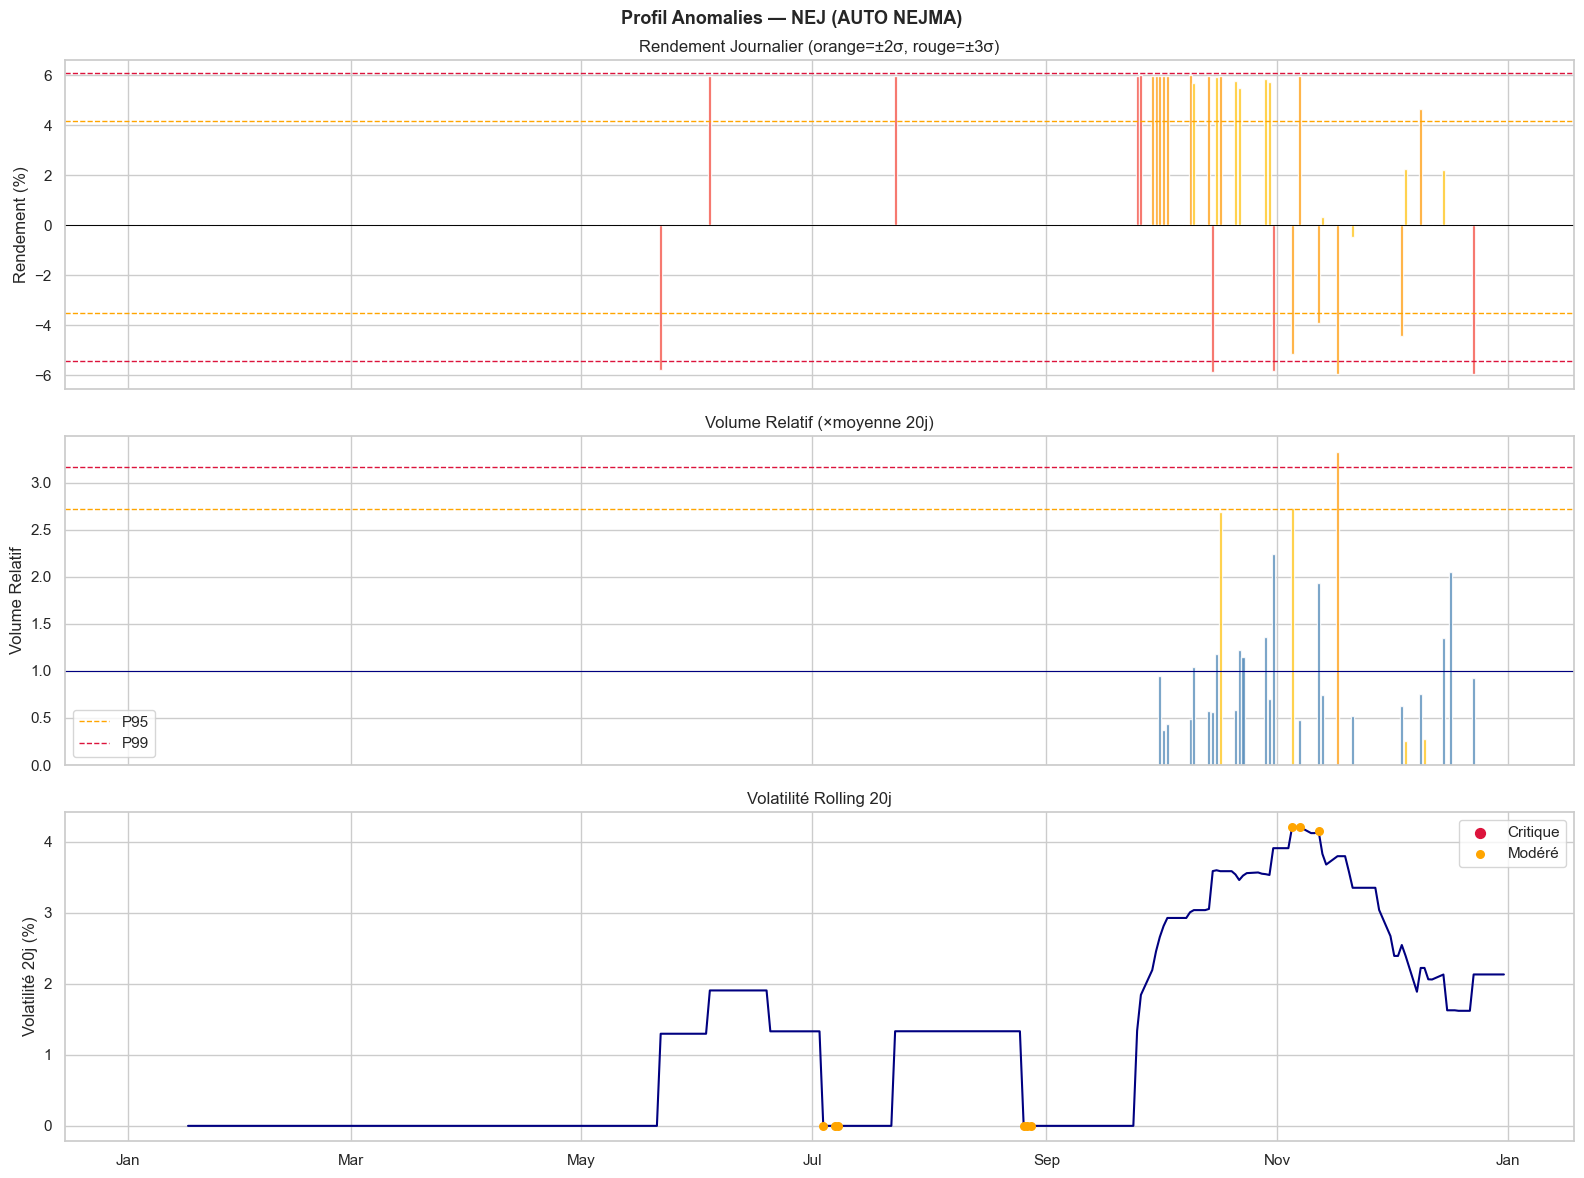

In [8]:
# Profil complet d'un instrument très alerté
top_alerte_ticker = df_instr_anom['Ticker'].value_counts().idxmax()
df_ex = df_instr[df_instr['Ticker'] == top_alerte_ticker].set_index('Jour').sort_index()
anom_ex = df_instr_anom[df_instr_anom['Ticker'] == top_alerte_ticker]
libelle_ex = df_ex['Libelle'].iloc[0] if 'Libelle' in df_ex.columns else top_alerte_ticker

print(f'Instrument le plus alerté : {top_alerte_ticker} — {libelle_ex}')
print(f'Nombre d\'anomalies : {len(anom_ex)}')

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Profil Anomalies — {top_alerte_ticker} ({libelle_ex})', fontsize=13, fontweight='bold')

# --- Rendement ---
rend = df_ex['Rendement_pct'].dropna()
rend_det = detect_multi_method(rend, methods=['zscore','rolling_zscore','percentile','iqr'])
colors_r = [sev_colors_map.get(s, 'steelblue') for s in rend_det['Severite_Finale']]
axes[0].bar(rend_det.index, rend_det['Valeur'], color=colors_r, alpha=0.85, width=0.8)
mu_r, s_r = rend.mean(), rend.std()
for k, c, ls in [(2, 'orange', '--'), (3, 'crimson', '--')]:
    axes[0].axhline(mu_r + k*s_r, color=c, linestyle=ls, linewidth=1)
    axes[0].axhline(mu_r - k*s_r, color=c, linestyle=ls, linewidth=1)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_ylabel('Rendement (%)')
axes[0].set_title('Rendement Journalier (orange=±2σ, rouge=±3σ)')

# --- Volume relatif ---
vol = df_ex['Volume_Relatif'].dropna()
vol_det2 = detect_multi_method(vol, methods=['zscore','percentile','iqr'])
colors_v = [sev_colors_map.get(s, 'steelblue') for s in vol_det2['Severite_Finale']]
axes[1].bar(vol_det2.index, vol_det2['Valeur'], color=colors_v, alpha=0.85, width=0.8)
axes[1].axhline(1.0, color='navy', linewidth=0.8, linestyle='-')
axes[1].axhline(vol.quantile(0.95), color='orange', linestyle='--', linewidth=1, label='P95')
axes[1].axhline(vol.quantile(0.99), color='crimson', linestyle='--', linewidth=1, label='P99')
axes[1].set_ylabel('Volume Relatif')
axes[1].set_title('Volume Relatif (×moyenne 20j)')
axes[1].legend()

# --- Volatilité ---
volat = df_ex['Volatilite_20j'].dropna()
volat_det = detect_multi_method(volat, methods=['zscore','rolling_zscore','percentile'])
colors_vol = [sev_colors_map.get(s, 'steelblue') for s in volat_det['Severite_Finale']]
axes[2].plot(volat_det.index, volat_det['Valeur'], color='navy', linewidth=1.5)
axes[2].scatter(
    volat_det[volat_det['Severite_Finale'] == CRITIQUE].index,
    volat_det[volat_det['Severite_Finale'] == CRITIQUE]['Valeur'],
    color='crimson', zorder=5, s=50, label='Critique'
)
axes[2].scatter(
    volat_det[volat_det['Severite_Finale'] == MODERE].index,
    volat_det[volat_det['Severite_Finale'] == MODERE]['Valeur'],
    color='orange', zorder=5, s=30, label='Modéré'
)
axes[2].set_ylabel('Volatilité 20j (%)')
axes[2].set_title('Volatilité Rolling 20j')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig(f'../reports/13_anomalies_{top_alerte_ticker}.png', dpi=150, bbox_inches='tight')
plt.show()

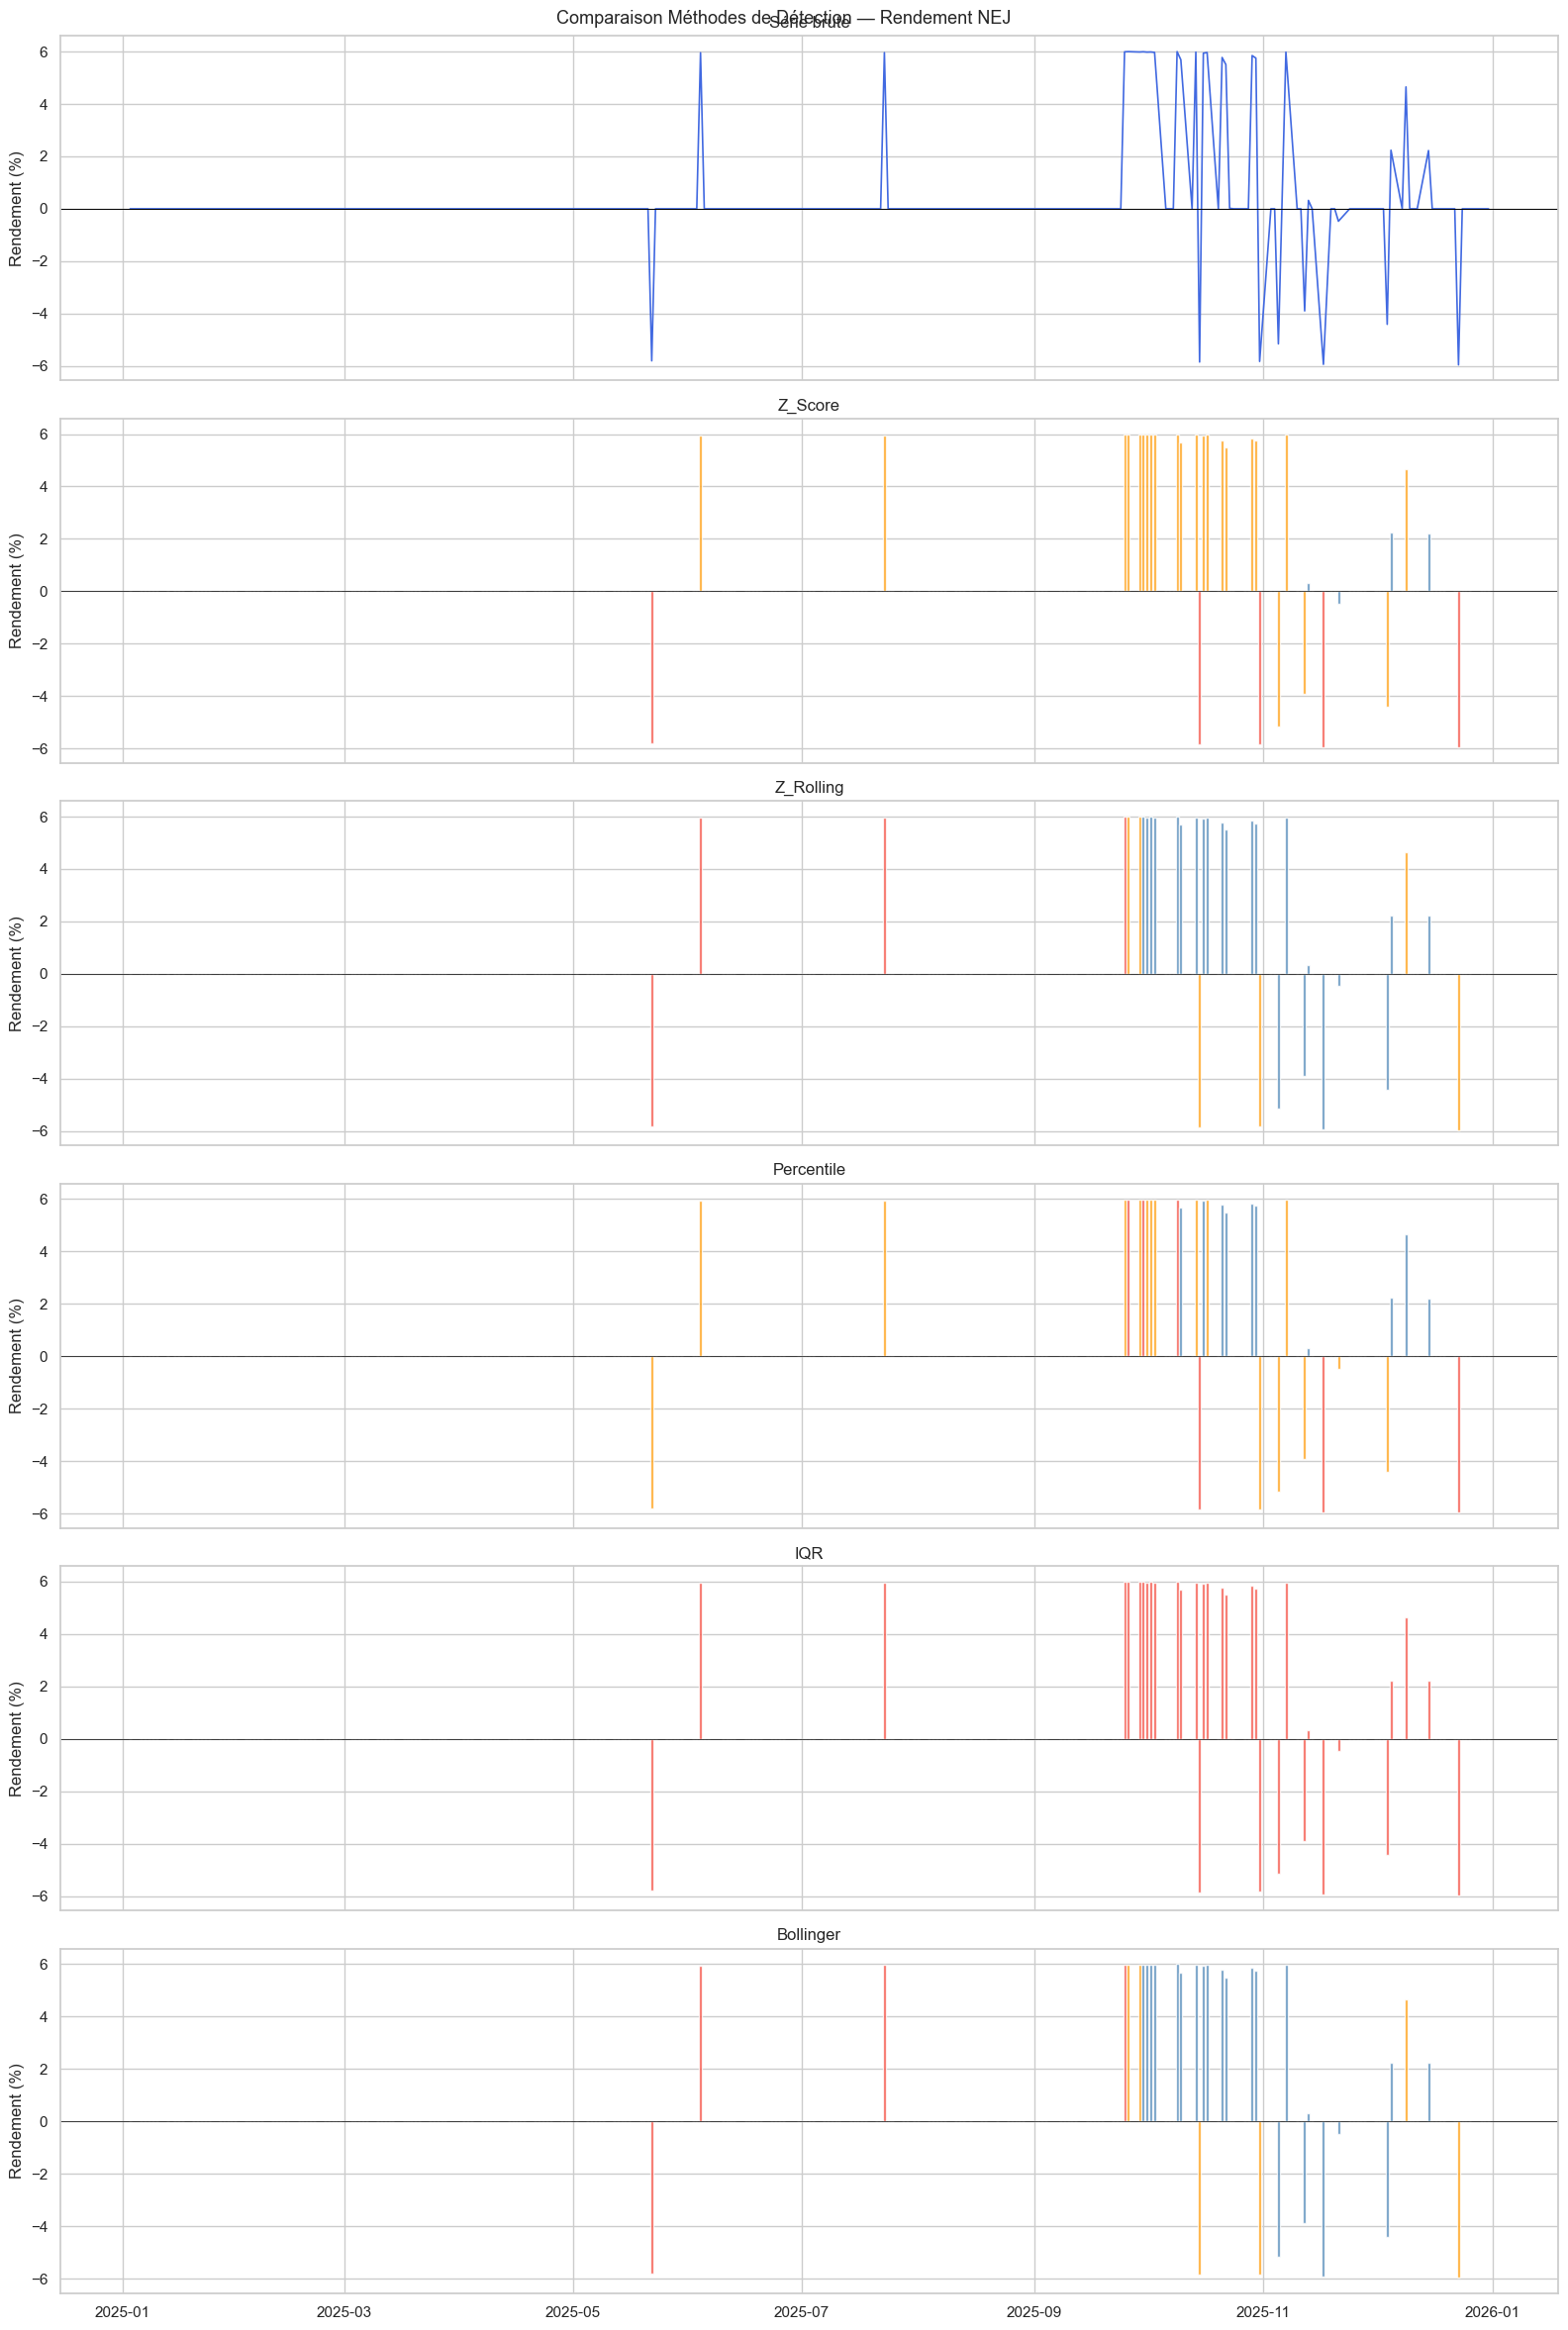


Consensus : Severite_Finale
Modéré      127
Faible      113
Critique      6


In [9]:
# Comparaison méthodes sur le rendement de ce ticker
rend_series = df_instr[df_instr['Ticker'] == top_alerte_ticker].set_index('Jour')['Rendement_pct'].dropna()
comp = detect_multi_method(rend_series, methods=['zscore','rolling_zscore','percentile','iqr','bollinger'])

method_cols = ['Z_Score','Z_Rolling','Percentile','IQR','Bollinger']
method_cols = [c for c in method_cols if c in comp.columns]

fig, axes = plt.subplots(len(method_cols)+1, 1, figsize=(16, 4*(len(method_cols)+1)), sharex=True)
fig.suptitle(f'Comparaison Méthodes de Détection — Rendement {top_alerte_ticker}', fontsize=13)

axes[0].plot(rend_series.index, rend_series.values, color='royalblue', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_ylabel('Rendement (%)')
axes[0].set_title('Série brute')

for i, method in enumerate(method_cols):
    ax = axes[i+1]
    colors = [sev_colors_map.get(s, 'steelblue') for s in comp[method]]
    ax.bar(rend_series.index, rend_series.values, color=colors, alpha=0.8, width=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Rendement (%)')
    ax.set_title(method)

plt.tight_layout()
plt.savefig(f'../reports/14_comparaison_methodes_{top_alerte_ticker}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nConsensus : {comp["Severite_Finale"].value_counts().to_string()}')

---
## 5. Détection — Flux d'Ordres (Intraday)

In [10]:
print('Détection anomalies flux d\'ordres...')
df_of_anom = detect_orderflow_anomalies(df_of)
print(f'\nAnomalies flux d\'ordres : {len(df_of_anom)}')
print(df_of_anom['Severite_Finale'].value_counts().to_string())
print('\nPar indicateur :')
print(df_of_anom['Indicateur'].value_counts().to_string())
display(df_of_anom.head(20))

Détection anomalies flux d'ordres...



Anomalies flux d'ordres : 1928
Severite_Finale
Faible      1238
Modéré       591
Critique      99

Par indicateur :
Indicateur
OIR                    527
VWAP_Dev_pct           398
Nb_Transactions        374
Volatilite_Intraday    367
OAR                    262


,Jour,Ticker,Libelle,Niveau,Indicateur,Description,Valeur,Severite_Finale,Score_Consensus,Nb_Methodes_Alerte
0,2025-12-26,AKT,AKT,Flux d'Ordres,Volatilite_Intraday,Volatilité intraday élevée,2.8190,Critique,3.0000,3
1,2025-12-24,ATL,ATL,Flux d'Ordres,Volatilite_Intraday,Volatilité intraday élevée,4.1882,Critique,3.0000,3
2,2025-12-24,BAL,BAL,Flux d'Ordres,VWAP_Dev_pct,Déviation VWAP vs clôture,0.0000,Critique,3.0000,3
3,2025-12-26,BOA,BOA,Flux d'Ordres,Volatilite_Intraday,Volatilité intraday élevée,2.6524,Critique,3.0000,3
4,2025-12-24,CDM,CDM,Flux d'Ordres,Volatilite_Intraday,Volatilité intraday élevée,3.3704,Critique,3.0000,3
5,2025-12-26,CSR,CSR,Flux d'Ordres,Volatilite_Intraday,Volatilité intraday élevée,2.2992,Critique,3.0000,3
6,2025-12-26,DHO,DHO,Flux d'Ordres,VWAP_Dev_pct,Déviation VWAP vs clôture,5.6791,Critique,3.0000,3
7,2025-12-29,DYT,DYT,Flux d'Ordres,Volatilite_Intraday,Volatilité intraday élevée,2.2572,Critique,3.0000,3
8,2025-12-29,DYT,DYT,Flux d'Ordres,VWAP_Dev_pct,Déviation VWAP vs clôture,-3.8721,Critique,3.0000,3
9,2025-12-30,EQD,EQD,Flux d'Ordres,OIR,Déséquilibre ordres (OIR),-0.6496,Critique,3.0000,3


In [11]:
# OIR — Détection avec Bollinger + Z-score
oir_all = df_of.set_index('Ticker').groupby('Ticker')['OIR'].mean().reset_index()
p99_oir = df_of['OIR'].abs().quantile(0.99)
p95_oir = df_of['OIR'].abs().quantile(0.95)

fig = px.scatter(
    df_of.dropna(subset=['OIR','OAR']),
    x='OAR', y='OIR',
    color='Ticker',
    size='Nb_Transactions',
    hover_data=['Jour','Ticker','Nb_Transactions','Volatilite_Intraday'],
    title='Espace OIR × OAR — Identification des Régimes Anormaux (Décembre 2025)',
    labels={'OIR': 'Order Imbalance Ratio (Lee-Ready)',
            'OAR': 'Order Arrival Rate (transactions/h)'}
)
fig.add_hline(y=p99_oir, line_dash='dash', line_color='crimson', annotation_text='P99 OIR')
fig.add_hline(y=-p99_oir, line_dash='dash', line_color='crimson')
fig.add_hline(y=p95_oir, line_dash='dot', line_color='orange', annotation_text='P95 OIR')
fig.add_hline(y=-p95_oir, line_dash='dot', line_color='orange')
fig.update_layout(height=550, showlegend=False)
fig.show()

---
## 6. Consolidation Globale des Anomalies

In [12]:
df_all_anom = consolidate_all_anomalies(df_market_anom, df_instr_anom, df_of_anom)
kpis = summarize_anomalies(df_all_anom)

print('╔══════════════════════════════════════════════╗')
print('║     RÉSUMÉ GLOBAL DES ANOMALIES — BVC 2025  ║')
print('╠══════════════════════════════════════════════╣')
for k, v in kpis.items():
    print(f'║  {k:<28} : {str(v):>10} ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║     RÉSUMÉ GLOBAL DES ANOMALIES — BVC 2025  ║
╠══════════════════════════════════════════════╣
║  Total                        :      18797 ║
║  Critique                     :       1839 ║
║  Modéré                       :       4747 ║
║  Faible                       :      12211 ║
║  Instruments_Alertés          :         77 ║
║  Indicateurs_Impliqués        :         17 ║
║  Jours_avec_Alerte            :        247 ║
║  Top_Ticker                   :        REB ║
╚══════════════════════════════════════════════╝


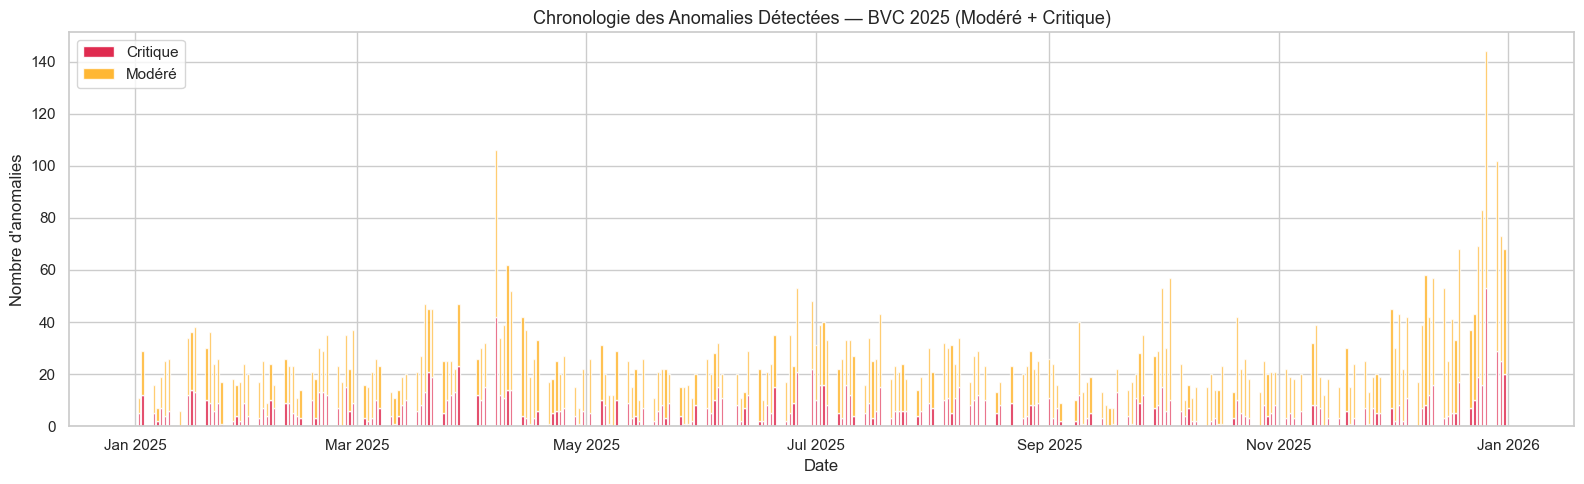

In [13]:
# Vue chronologique : nb anomalies critiques par jour
daily_anom = (df_all_anom[df_all_anom['Severite_Finale'].isin([MODERE, CRITIQUE])]
              .groupby(['Jour', 'Severite_Finale'])
              .size().unstack(fill_value=0).reset_index())

fig, ax = plt.subplots(figsize=(16, 5))
if CRITIQUE in daily_anom.columns:
    ax.bar(daily_anom['Jour'], daily_anom.get(CRITIQUE, 0),
           color='crimson', alpha=0.9, label='Critique', width=0.6)
if MODERE in daily_anom.columns:
    bottom = daily_anom.get(CRITIQUE, pd.Series(0, index=daily_anom.index))
    ax.bar(daily_anom['Jour'], daily_anom.get(MODERE, 0),
           bottom=bottom, color='orange', alpha=0.8, label='Modéré', width=0.6)

ax.set_xlabel('Date')
ax.set_ylabel('Nombre d\'anomalies')
ax.set_title('Chronologie des Anomalies Détectées — BVC 2025 (Modéré + Critique)', fontsize=13)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('../reports/15_chronologie_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

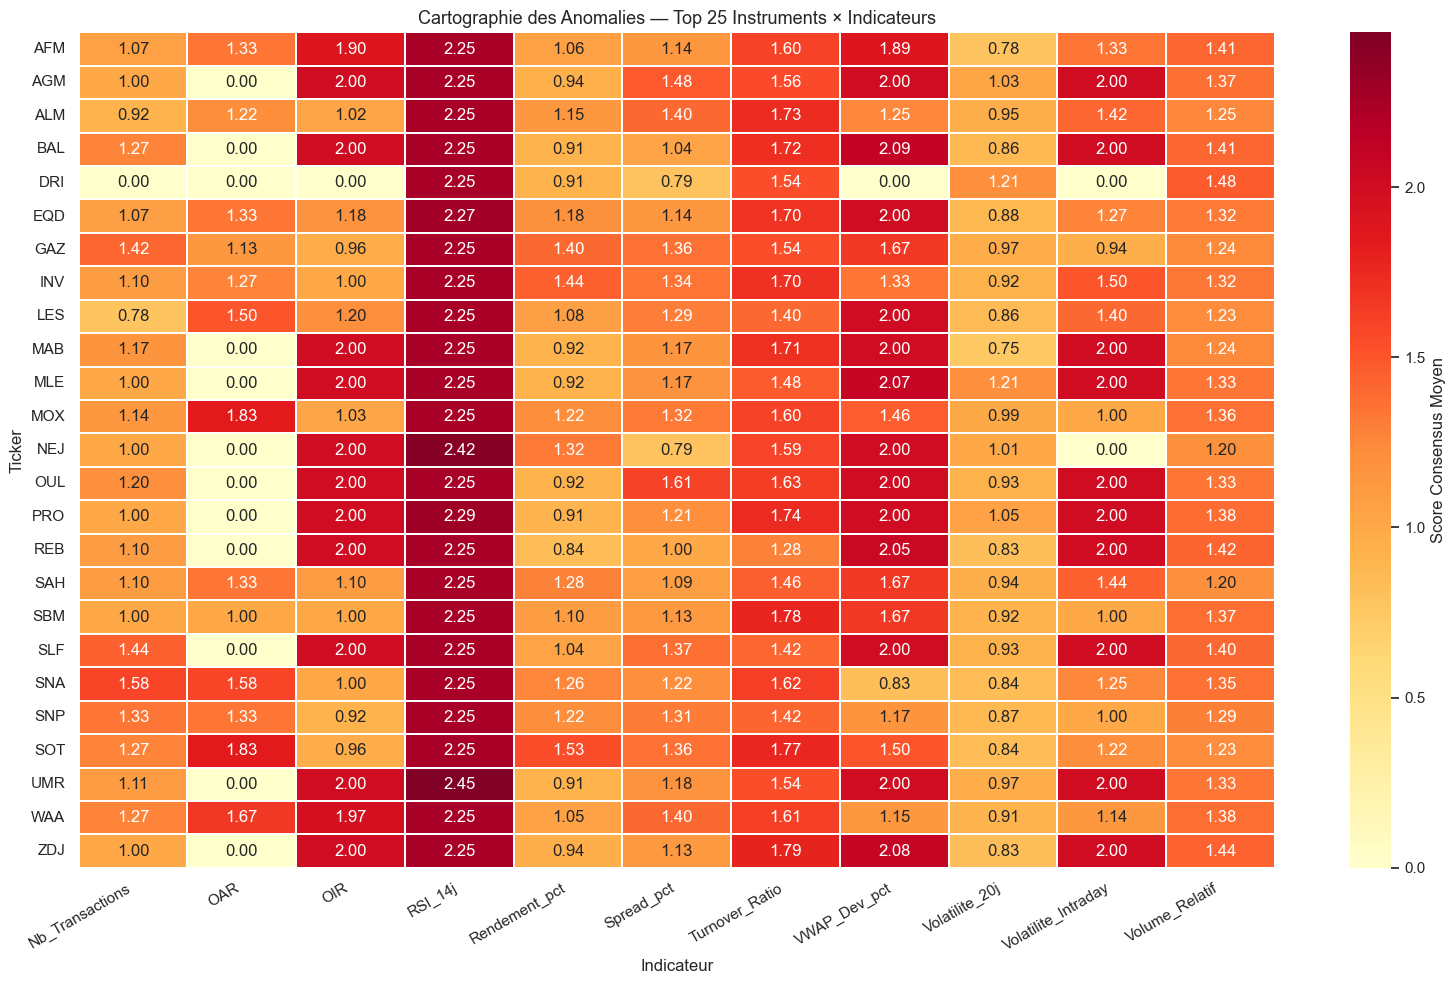

In [14]:
# Heatmap : score d'anomalie par (Ticker × Indicateur)
if 'Ticker' in df_all_anom.columns and 'Indicateur' in df_all_anom.columns:
    pivot_anom = (df_all_anom[df_all_anom['Ticker'] != 'MARCHE']
                  .groupby(['Ticker','Indicateur'])['Score_Consensus'].mean()
                  .unstack(fill_value=0))
    top_tickers = (df_all_anom[df_all_anom['Ticker'] != 'MARCHE']
                   .groupby('Ticker').size().nlargest(25).index)
    pivot_anom = pivot_anom.loc[pivot_anom.index.isin(top_tickers)]

    plt.figure(figsize=(16, 10))
    sns.heatmap(pivot_anom, cmap='YlOrRd', annot=True, fmt='.2f',
                linewidths=0.3, cbar_kws={'label': 'Score Consensus Moyen'})
    plt.title('Cartographie des Anomalies — Top 25 Instruments × Indicateurs', fontsize=13)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/16_heatmap_anomalies_full.png', dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
# Graphique radar : top 10 instruments les plus surveillés
top10 = (df_instr_anom[df_instr_anom['Severite_Finale'] == CRITIQUE]
         .groupby('Ticker').size().nlargest(10).reset_index(name='Nb_Critiques'))

fig = px.bar(top10, x='Ticker', y='Nb_Critiques',
             title='Top 10 Instruments avec le Plus d\'Anomalies Critiques',
             color='Nb_Critiques', color_continuous_scale='Reds',
             text_auto=True)
fig.update_layout(height=400)
fig.show()

---
## 7. Sauvegarde et Export pour Validation

In [16]:
# Sauvegarde Parquet
df_all_anom.to_parquet('../data/all_anomalies.parquet', index=False)
df_seuils.to_csv('../data/seuils_phase3.csv', index=False)

# Export Excel structuré pour validation encadrante
output_excel = export_anomalies_excel(
    df_all_anom, df_seuils,
    df_market_anom, df_instr_anom, df_of_anom,
    output_path='../reports/anomalies_statistiques_2025.xlsx'
)
print(f'✓ Parquet sauvegardé : data/all_anomalies.parquet')
print(f'✓ Excel exporté : {output_excel}')

import os
size_kb = os.path.getsize('../reports/anomalies_statistiques_2025.xlsx') / 1024
print(f'  Taille : {size_kb:.0f} KB')

✓ Parquet sauvegardé : data/all_anomalies.parquet
✓ Excel exporté : ../reports/anomalies_statistiques_2025.xlsx
  Taille : 1974 KB


In [17]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║        PHASE 3 — DÉTECTION STATISTIQUE COMPLÉTÉE               ║
╠══════════════════════════════════════════════════════════════════╣
║ MÉTHODES APPLIQUÉES                                              ║
║   ✓ Z-score statique (μ ± 2σ / μ ± 3σ)                         ║
║   ✓ Z-score rolling (fenêtre 20j)                               ║
║   ✓ Percentiles P95 / P99                                       ║
║   ✓ IQR — Tukey (robuste outliers)                              ║
║   ✓ Bandes de Bollinger (adaptatif)                             ║
║   ✓ CUSUM (dérives graduelles)                                  ║
║   ✓ Consensus multi-méthodes (vote)                             ║
╠══════════════════════════════════════════════════════════════════╣
║ NIVEAUX ANALYSÉS                                                 ║
║   ✓ Marché global (MASI, volume, breadth, HHI)                  ║
║   ✓ Par instrument (rendement, vol, vol.rel., spread, RSI)      ║
║   ✓ Flux d'ordres (OIR, OAR, VWAP dev, volatilité intraday)    ║
╠══════════════════════════════════════════════════════════════════╣
║ EXPORTS                                                          ║
║   ✓ data/all_anomalies.parquet                                   ║
║   ✓ reports/anomalies_statistiques_2025.xlsx (6 feuilles)       ║
║   ✓ 5 graphiques supplémentaires dans reports/                  ║
╠══════════════════════════════════════════════════════════════════╣
║ PROCHAINE ÉTAPE → Phase 4 : Dashboard Streamlit + Upload Excel  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║        PHASE 3 — DÉTECTION STATISTIQUE COMPLÉTÉE               ║
╠══════════════════════════════════════════════════════════════════╣
║ MÉTHODES APPLIQUÉES                                              ║
║   ✓ Z-score statique (μ ± 2σ / μ ± 3σ)                         ║
║   ✓ Z-score rolling (fenêtre 20j)                               ║
║   ✓ Percentiles P95 / P99                                       ║
║   ✓ IQR — Tukey (robuste outliers)                              ║
║   ✓ Bandes de Bollinger (adaptatif)                             ║
║   ✓ CUSUM (dérives graduelles)                                  ║
║   ✓ Consensus multi-méthodes (vote)                             ║
╠══════════════════════════════════════════════════════════════════╣
║ NIVEAUX ANALYSÉS                                                 ║
║   ✓ Marché global (MASI, volume, breadth, HHI)                  ║
║   ✓ Par instrument (rendement, vol, vol.re